# HANS Lexical-Overlap Subcase Analysis

This notebook examines the lexical-overlap non-entailment HANS examples
in more detail.

The goal is to determine whether the FP32-to-INT8 degradation is spread
across lexical-overlap subcases or concentrated in particular syntactic
constructions.

In [2]:
import pandas as pd
from pathlib import Path

In [3]:
SEEDS = [42, 123, 456]

RESULTS_DIR = Path("../results/hans")

print("Seeds:", SEEDS)
print("Results directory:", RESULTS_DIR)

Seeds: [42, 123, 456]
Results directory: ../results/hans


In [4]:
results = {}

for seed in SEEDS:
    fp32_path = RESULTS_DIR / f"fp32_seed{seed}_predictions.csv"
    int8_path = RESULTS_DIR / f"int8_seed{seed}_predictions.csv"

    fp32 = pd.read_csv(fp32_path)
    int8 = pd.read_csv(int8_path)

    results[seed] = {
        "fp32": fp32,
        "int8": int8
    }

    print(
        f"Seed {seed}: "
        f"FP32 = {len(fp32)}, "
        f"INT8 = {len(int8)}"
    )

Seed 42: FP32 = 30000, INT8 = 30000
Seed 123: FP32 = 30000, INT8 = 30000
Seed 456: FP32 = 30000, INT8 = 30000


## Validate FP32 and INT8 Predictions

Before comparing subcases, verify that the FP32 and INT8 files contain
the same HANS examples for each seed.

In [5]:
for seed in SEEDS:
    fp32 = results[seed]["fp32"]
    int8 = results[seed]["int8"]

    same_pairs = set(fp32["pairID"]) == set(int8["pairID"])

    print(f"Seed {seed}: same pairIDs = {same_pairs}")

Seed 42: same pairIDs = True
Seed 123: same pairIDs = True
Seed 456: same pairIDs = True


## Select Lexical-Overlap Non-Entailment Examples

Focus on examples where the lexical-overlap heuristic suggests entailment
but the correct HANS label is non-entailment.

In [6]:
lexical_results = {}

for seed in SEEDS:
    fp32 = results[seed]["fp32"]
    int8 = results[seed]["int8"]

    fp32_lexical = fp32[
        (fp32["heuristic"] == "lexical_overlap") &
        (fp32["gold_label"] == "non-entailment")
    ].copy()

    int8_lexical = int8[
        (int8["heuristic"] == "lexical_overlap") &
        (int8["gold_label"] == "non-entailment")
    ].copy()

    lexical_results[seed] = {
        "fp32": fp32_lexical,
        "int8": int8_lexical
    }

    print(
        f"Seed {seed}: "
        f"FP32 = {len(fp32_lexical)}, "
        f"INT8 = {len(int8_lexical)}"
    )

Seed 42: FP32 = 5000, INT8 = 5000
Seed 123: FP32 = 5000, INT8 = 5000
Seed 456: FP32 = 5000, INT8 = 5000


In [7]:
subcases = sorted(
    lexical_results[42]["fp32"]["subcase"].unique()
)

print("Lexical-overlap non-entailment subcases:")

for subcase in subcases:
    print(subcase)

Lexical-overlap non-entailment subcases:
ln_conjunction
ln_passive
ln_preposition
ln_relative_clause
ln_subject/object_swap


## FP32 vs INT8 Accuracy by Subcase

Calculate the accuracy of FP32 and INT8 for each lexical-overlap
non-entailment subcase and measure the change caused by quantization.

In [8]:
subcase_rows = []

for seed in SEEDS:
    fp32 = lexical_results[seed]["fp32"]
    int8 = lexical_results[seed]["int8"]

    for subcase in subcases:
        fp32_sub = fp32[fp32["subcase"] == subcase]
        int8_sub = int8[int8["subcase"] == subcase]

        fp32_accuracy = fp32_sub["correct"].mean()
        int8_accuracy = int8_sub["correct"].mean()

        subcase_rows.append({
            "seed": seed,
            "subcase": subcase,
            "fp32_accuracy": fp32_accuracy,
            "int8_accuracy": int8_accuracy,
            "change": int8_accuracy - fp32_accuracy
        })

subcase_df = pd.DataFrame(subcase_rows)

subcase_df

,seed,subcase,fp32_accuracy,int8_accuracy,change
0,42,ln_conjunction,0.624,0.591,-0.033
1,42,ln_passive,0.003,0.001,-0.002
2,42,ln_preposition,0.590,0.533,-0.057
3,42,ln_relative_clause,0.478,0.433,-0.045
4,42,ln_subject/object_swap,0.445,0.387,-0.058
5,123,ln_conjunction,0.471,0.414,-0.057
6,123,ln_passive,0.013,0.005,-0.008
7,123,ln_preposition,0.634,0.576,-0.058
8,123,ln_relative_clause,0.541,0.465,-0.076
9,123,ln_subject/object_swap,0.616,0.521,-0.095


In [9]:
display_df = subcase_df.copy()

display_df["fp32_accuracy"] *= 100
display_df["int8_accuracy"] *= 100
display_df["change"] *= 100

display_df = display_df.round(2)

display_df

,seed,subcase,fp32_accuracy,int8_accuracy,change
0,42,ln_conjunction,62.4,59.1,-3.3
1,42,ln_passive,0.3,0.1,-0.2
2,42,ln_preposition,59.0,53.3,-5.7
3,42,ln_relative_clause,47.8,43.3,-4.5
4,42,ln_subject/object_swap,44.5,38.7,-5.8
5,123,ln_conjunction,47.1,41.4,-5.7
6,123,ln_passive,1.3,0.5,-0.8
7,123,ln_preposition,63.4,57.6,-5.8
8,123,ln_relative_clause,54.1,46.5,-7.6
9,123,ln_subject/object_swap,61.6,52.1,-9.5


## Prediction Flips by Subcase

Count harmful and beneficial FP32-to-INT8 prediction changes within each
lexical-overlap non-entailment subcase.

In [10]:
paired_results = {}

for seed in SEEDS:
    fp32 = lexical_results[seed]["fp32"]
    int8 = lexical_results[seed]["int8"]

    paired = fp32.merge(
        int8,
        on="pairID",
        suffixes=("_fp32", "_int8")
    )

    paired_results[seed] = paired

    print(f"Seed {seed}: paired examples = {len(paired)}")

Seed 42: paired examples = 5000
Seed 123: paired examples = 5000
Seed 456: paired examples = 5000


In [11]:
flip_rows = []

for seed in SEEDS:
    paired = paired_results[seed]

    for subcase in subcases:
        sub = paired[
            paired["subcase_fp32"] == subcase
        ]

        harmful = (
            (sub["correct_fp32"] == True) &
            (sub["correct_int8"] == False)
        ).sum()

        beneficial = (
            (sub["correct_fp32"] == False) &
            (sub["correct_int8"] == True)
        ).sum()

        flip_rows.append({
            "seed": seed,
            "subcase": subcase,
            "harmful_flips": harmful,
            "beneficial_flips": beneficial,
            "net_flips": harmful - beneficial
        })

flip_df = pd.DataFrame(flip_rows)

flip_df

,seed,subcase,harmful_flips,beneficial_flips,net_flips
0,42,ln_conjunction,38,5,33
1,42,ln_passive,2,0,2
2,42,ln_preposition,61,4,57
3,42,ln_relative_clause,51,6,45
4,42,ln_subject/object_swap,64,6,58
5,123,ln_conjunction,62,5,57
6,123,ln_passive,8,0,8
7,123,ln_preposition,61,3,58
8,123,ln_relative_clause,77,1,76
9,123,ln_subject/object_swap,95,0,95


## Entailment Probability Shift by Subcase

Measure whether quantization moves predictions toward the lexical-overlap
heuristic even when the final predicted label does not change.

In [12]:
probability_rows = []

for seed in SEEDS:
    paired = paired_results[seed]

    for subcase in subcases:
        sub = paired[
            paired["subcase_fp32"] == subcase
        ]

        entailment_shift = (
            sub["prob_entailment_int8"] -
            sub["prob_entailment_fp32"]
        ).mean()

        probability_rows.append({
            "seed": seed,
            "subcase": subcase,
            "mean_entailment_probability_shift": entailment_shift
        })

probability_df = pd.DataFrame(probability_rows)

probability_df

,seed,subcase,mean_entailment_probability_shift
0,42,ln_conjunction,0.030633
1,42,ln_passive,0.010057
2,42,ln_preposition,0.038239
3,42,ln_relative_clause,0.029724
4,42,ln_subject/object_swap,0.053807
5,123,ln_conjunction,0.038462
6,123,ln_passive,0.017108
7,123,ln_preposition,0.049229
8,123,ln_relative_clause,0.052450
9,123,ln_subject/object_swap,0.066105


In [13]:
probability_display = probability_df.copy()

probability_display["mean_entailment_probability_shift"] *= 100
probability_display["mean_entailment_probability_shift"] = (
    probability_display["mean_entailment_probability_shift"].round(2)
)

probability_display

,seed,subcase,mean_entailment_probability_shift
0,42,ln_conjunction,3.06
1,42,ln_passive,1.01
2,42,ln_preposition,3.82
3,42,ln_relative_clause,2.97
4,42,ln_subject/object_swap,5.38
5,123,ln_conjunction,3.85
6,123,ln_passive,1.71
7,123,ln_preposition,4.92
8,123,ln_relative_clause,5.25
9,123,ln_subject/object_swap,6.61


## Across-Seed Subcase Summary

Summarize the FP32-to-INT8 accuracy and entailment-probability changes
across the three seeds for each lexical-overlap non-entailment subcase.

In [14]:
accuracy_summary = (
    subcase_df
    .groupby("subcase")["change"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

probability_summary = (
    probability_df
    .groupby("subcase")["mean_entailment_probability_shift"]
    .mean()
    .reset_index()
)

subcase_summary = accuracy_summary.merge(
    probability_summary,
    on="subcase"
)

subcase_summary["mean_accuracy_change"] = subcase_summary["mean"] * 100
subcase_summary["min_accuracy_change"] = subcase_summary["min"] * 100
subcase_summary["max_accuracy_change"] = subcase_summary["max"] * 100
subcase_summary["mean_entailment_probability_shift"] *= 100

subcase_summary = subcase_summary[
    [
        "subcase",
        "mean_accuracy_change",
        "min_accuracy_change",
        "max_accuracy_change",
        "mean_entailment_probability_shift"
    ]
].round(2)

subcase_summary

,subcase,mean_accuracy_change,min_accuracy_change,max_accuracy_change,mean_entailment_probability_shift
0,ln_conjunction,-4.80,-5.7,-3.3,3.51
1,ln_passive,-0.33,-0.8,0.0,0.99
2,ln_preposition,-5.57,-5.8,-5.2,4.14
3,ln_relative_clause,-5.00,-7.6,-2.9,3.69
4,ln_subject/object_swap,-5.90,-9.5,-2.4,4.92


The lexical-overlap non-entailment degradation is not concentrated in a
single HANS subcase.

For conjunction, preposition, relative-clause, and subject/object-swap
examples, INT8 accuracy decreases for all three seeds. These subcases also
show more harmful than beneficial prediction flips and a positive shift in
entailment probability after quantization.

Subject/object-swap shows the largest mean accuracy decrease (-5.90
percentage points), followed by preposition (-5.57), relative clause (-5.00),
and conjunction (-4.80).

Passive examples are already near the FP32 accuracy floor, so additional
accuracy degradation is difficult to observe in that subcase. Its mean
entailment probability nevertheless shifts slightly upward after
quantization.

Overall, the lexical-overlap effect appears across multiple syntactic
constructions rather than being driven by a single subcase.

In [16]:
output_dir = RESULTS_DIR / "subcase_analysis"
output_dir.mkdir(exist_ok=True)

display_df.to_csv(
    output_dir / "lexical_nonentailment_accuracy_by_subcase.csv",
    index=False
)

flip_df.to_csv(
    output_dir / "lexical_nonentailment_flips_by_subcase.csv",
    index=False
)

subcase_summary.to_csv(
    output_dir / "lexical_nonentailment_summary.csv",
    index=False
)

probability_display.to_csv(
    output_dir / "lexical_nonentailment_probability_shift_by_subcase.csv",
    index=False
)

print("Results saved to:", output_dir)

Results saved to: ../results/hans/subcase_analysis


## Accuracy Change by Subcase

Visualize the FP32-to-INT8 accuracy change for each lexical-overlap
non-entailment subcase across the three seeds.

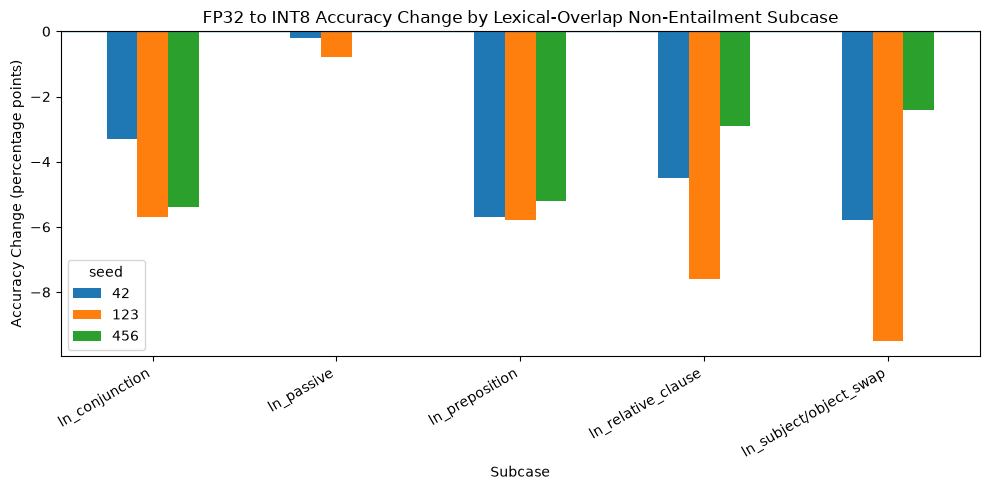

In [17]:
import matplotlib.pyplot as plt

plot_df = display_df.pivot(
    index="subcase",
    columns="seed",
    values="change"
)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.axhline(0, linewidth=1)

ax.set_title(
    "FP32 to INT8 Accuracy Change by Lexical-Overlap Non-Entailment Subcase"
)
ax.set_xlabel("Subcase")
ax.set_ylabel("Accuracy Change (percentage points)")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
figure_path = output_dir / "lexical_nonentailment_accuracy_change.png"

fig = ax.get_figure()
fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", figure_path)